<a href="https://colab.research.google.com/github/Piyush22105061/saas_churn_retention_analysis/blob/main/notebooks/03a_cohort_retention.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install -q sqlalchemy psycopg2-binary pandas openpyxl

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.3/4.3 MB 28.3 MB/s eta 0:00:00


In [ ]:
from sqlalchemy import create_engine
import pandas as pd

HOST = "aws-0-ap-south-1.pooler.supabase.com"
PORT = 5432
DATABASE = "postgres"

USERNAME = "saas_ro_user.imnzftquwjuxcwpeufwp"
PASSWORD = "saas-read-only"      # Replace with your actual password

SCHEMA = "saas"

engine = create_engine(
    f"postgresql+psycopg2://{USERNAME}:{PASSWORD}@{HOST}:{PORT}/{DATABASE}"
)

print("Connected!")

Connected!


In [ ]:
subscriptions = pd.read_sql(
    "SELECT * FROM saas.subscriptions",
    engine,
    parse_dates=["start_date","end_date","cancelled_at"]
)

plans = pd.read_sql(
    "SELECT * FROM saas.plans",
    engine
)

accounts = pd.read_sql(
    "SELECT * FROM saas.accounts",
    engine
)

In [ ]:
print(subscriptions.shape)
print(plans.shape)
print(accounts.shape)

(2113, 12)
(8, 5)
(1250, 8)


In [ ]:
subscriptions.head()

,subscription_id,user_id,plan,start_date,end_date,mrr,status,cancelled_at,cancellation_reason,account_id,seat_count,plan_id
0,822,625.0,pro,2024-04-07,NaT,63.96,paused,NaT,None,100625,1,NaN
1,69,438.0,Pro,2023-02-15,NaT,84.05,past_due,NaT,None,100438,1,NaN
2,94,679.0,Pro,2025-08-16,NaT,68.15,past_due,NaT,None,100679,1,NaN
3,122,947.0,professional,2023-11-14,NaT,163.96,paused,NaT,None,100947,1,NaN
4,176,769.0,enterprise,2026-03-23,NaT,532.99,past_due,NaT,None,100769,1,NaN


In [ ]:
subscriptions.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2113 entries, 0 to 2112
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   subscription_id      2113 non-null   int64         
 1   user_id              2000 non-null   float64       
 2   plan                 2113 non-null   object        
 3   start_date           2113 non-null   datetime64[ns]
 4   end_date             1646 non-null   datetime64[ns]
 5   mrr                  2113 non-null   float64       
 6   status               2113 non-null   object        
 7   cancelled_at         557 non-null    datetime64[ns]
 8   cancellation_reason  469 non-null    object        
 9   account_id           2113 non-null   int64         
 10  seat_count           2113 non-null   int64         
 11  plan_id              1870 non-null   float64       
dtypes: datetime64[ns](3), float64(3), int64(3), object(3)
memory usage: 198.2+ KB


In [ ]:
subscriptions["status"].value_counts()

,count
status,
active,885
churned,557
trialing,292
past_due,195
paused,184


In [ ]:
subscriptions["plan"].value_counts(dropna=False)

,count
plan,
pro,348
starter,347
professional,294
enterprise,287
Enterprise,285
Pro,282
free,270


In [ ]:
subscriptions["plan"] = (
    subscriptions["plan"]
    .str.lower()
    .replace({
        "professional":"pro",
        "Pro":'pro'
    })
)

In [ ]:
subscriptions["plan"].value_counts(dropna=False)

,count
plan,
pro,924
enterprise,572
starter,347
free,270


In [ ]:
today = pd.Timestamp.today().normalize()

active = subscriptions[
    (subscriptions["status"]=="active") &
    (
        subscriptions["end_date"].isna() |
        (subscriptions["end_date"]>today)
    )
].copy()

In [ ]:
active

,subscription_id,user_id,plan,start_date,end_date,mrr,status,cancelled_at,cancellation_reason,account_id,seat_count,plan_id
42,2,698.0,enterprise,2026-04-22,2028-02-10,584.95,active,NaT,None,100698,1,NaN
45,84,442.0,free,2026-01-22,2027-01-25,0.00,active,NaT,None,100442,1,NaN
52,164,970.0,pro,2026-01-19,2026-10-26,166.41,active,NaT,None,100970,1,NaN
53,193,282.0,pro,2025-08-29,2027-02-19,91.60,active,NaT,None,100282,1,NaN
61,260,393.0,pro,2025-10-27,2026-09-21,71.37,active,NaT,None,100393,1,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
2105,2106,NaN,enterprise,2024-08-11,NaT,399.00,active,NaT,None,200228,1,4.0
2107,2108,NaN,pro,2025-04-09,NaT,396.00,active,NaT,None,200233,4,3.0
2108,2109,NaN,starter,2025-10-25,NaT,29.00,active,NaT,None,200235,1,2.0
2109,2110,NaN,pro,2024-10-09,NaT,396.00,active,NaT,None,200236,4,3.0


In [ ]:
paid_active = active[
    active["plan"]!="free"
]

In [ ]:
paid_active

,subscription_id,user_id,plan,start_date,end_date,mrr,status,cancelled_at,cancellation_reason,account_id,seat_count,plan_id
42,2,698.0,enterprise,2026-04-22,2028-02-10,584.95,active,NaT,None,100698,1,NaN
52,164,970.0,pro,2026-01-19,2026-10-26,166.41,active,NaT,None,100970,1,NaN
53,193,282.0,pro,2025-08-29,2027-02-19,91.60,active,NaT,None,100282,1,NaN
61,260,393.0,pro,2025-10-27,2026-09-21,71.37,active,NaT,None,100393,1,NaN
63,264,520.0,starter,2026-04-02,2027-06-01,26.35,active,NaT,None,100520,1,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
2105,2106,NaN,enterprise,2024-08-11,NaT,399.00,active,NaT,None,200228,1,4.0
2107,2108,NaN,pro,2025-04-09,NaT,396.00,active,NaT,None,200233,4,3.0
2108,2109,NaN,starter,2025-10-25,NaT,29.00,active,NaT,None,200235,1,2.0
2109,2110,NaN,pro,2024-10-09,NaT,396.00,active,NaT,None,200236,4,3.0


In [ ]:
current_mrr = paid_active["mrr"].sum()

print(f"Current Paid MRR : ${current_mrr:,.2f}")

Current Paid MRR : $167,707.28


In [ ]:
mrr_by_plan = (
    paid_active
    .groupby("plan")
    .agg(
        Active_Subscriptions=("subscription_id","count"),
        Accounts=("account_id","nunique"),
        MRR=("mrr","sum")
    )
    .sort_values("MRR",ascending=False)
)

mrr_by_plan

,Active_Subscriptions,Accounts,MRR
plan,,,
enterprise,113,106,109815.18
pro,200,186,51065.98
starter,90,87,6826.12


In [ ]:
months = pd.date_range(
    subscriptions["start_date"].min().normalize(),
    today,
    freq="MS"
)

In [ ]:
months

DatetimeIndex(['2022-04-01', '2022-05-01', '2022-06-01', '2022-07-01',
               '2022-08-01', '2022-09-01', '2022-10-01', '2022-11-01',
               '2022-12-01', '2023-01-01', '2023-02-01', '2023-03-01',
               '2023-04-01', '2023-05-01', '2023-06-01', '2023-07-01',
               '2023-08-01', '2023-09-01', '2023-10-01', '2023-11-01',
               '2023-12-01', '2024-01-01', '2024-02-01', '2024-03-01',
               '2024-04-01', '2024-05-01', '2024-06-01', '2024-07-01',
               '2024-08-01', '2024-09-01', '2024-10-01', '2024-11-01',
               '2024-12-01', '2025-01-01', '2025-02-01', '2025-03-01',
               '2025-04-01', '2025-05-01', '2025-06-01', '2025-07-01',
               '2025-08-01', '2025-09-01', '2025-10-01', '2025-11-01',
               '2025-12-01', '2026-01-01', '2026-02-01', '2026-03-01',
               '2026-04-01', '2026-05-01', '2026-06-01', '2026-07-01'],
              dtype='datetime64[ns]', freq='MS')

In [ ]:
records = []

for month in months:

    month_end = month + pd.offsets.MonthEnd(0)

    active_start = subscriptions[
        (subscriptions["start_date"] < month) &
        (
            subscriptions["end_date"].isna() |
            (subscriptions["end_date"] >= month)
        ) &
        (subscriptions["plan"]!="free")
    ]

    churned = subscriptions[
        subscriptions["cancelled_at"].between(
            month,
            month_end
        ) &
        (subscriptions["plan"]!="free")
    ]

    active_accounts = active_start["account_id"].nunique()

    churn_accounts = churned["account_id"].nunique()

    churn_rate = (
        churn_accounts*100/active_accounts
        if active_accounts else np.nan
    )

    records.append({
        "Month":month,
        "Active Accounts":active_accounts,
        "Churned":churn_accounts,
        "Paid Churn Rate %":churn_rate
    })

monthly_paid = pd.DataFrame(records)

In [ ]:
monthly_paid

,Month,Active Accounts,Churned,Paid Churn Rate %
0,2022-04-01,1,0,0.000000
1,2022-05-01,2,0,0.000000
2,2022-06-01,4,0,0.000000
3,2022-07-01,8,0,0.000000
4,2022-08-01,11,0,0.000000
5,2022-09-01,13,0,0.000000
6,2022-10-01,21,0,0.000000
7,2022-11-01,26,1,3.846154
8,2022-12-01,33,0,0.000000
9,2023-01-01,35,1,2.857143


In [ ]:
records = []

for month in months:

    month_end = month + pd.offsets.MonthEnd(0)

    active_start = subscriptions[
        (subscriptions["start_date"] < month) &
        (
            subscriptions["end_date"].isna() |
            (subscriptions["end_date"] >= month)
        ) &
        (subscriptions["plan"]=="free")
    ]

    churned = subscriptions[
        subscriptions["cancelled_at"].between(
            month,
            month_end
        ) &
        (subscriptions["plan"]=="free")
    ]

    active_accounts = active_start["account_id"].nunique()

    churn_accounts = churned["account_id"].nunique()

    churn_rate = (
        churn_accounts*100/active_accounts
        if active_accounts else np.nan
    )

    records.append({
        "Month":month,
        "Active Accounts":active_accounts,
        "Churned":churn_accounts,
        "Free Churn Rate %":churn_rate
    })

monthly_free = pd.DataFrame(records)

In [ ]:
monthly_free

,Month,Active Accounts,Churned,Free Churn Rate %
0,2022-04-01,0,0,NaN
1,2022-05-01,0,0,NaN
2,2022-06-01,0,0,NaN
3,2022-07-01,1,0,0.000000
4,2022-08-01,2,0,0.000000
5,2022-09-01,3,0,0.000000
6,2022-10-01,3,0,0.000000
7,2022-11-01,3,1,33.333333
8,2022-12-01,3,0,0.000000
9,2023-01-01,6,1,16.666667


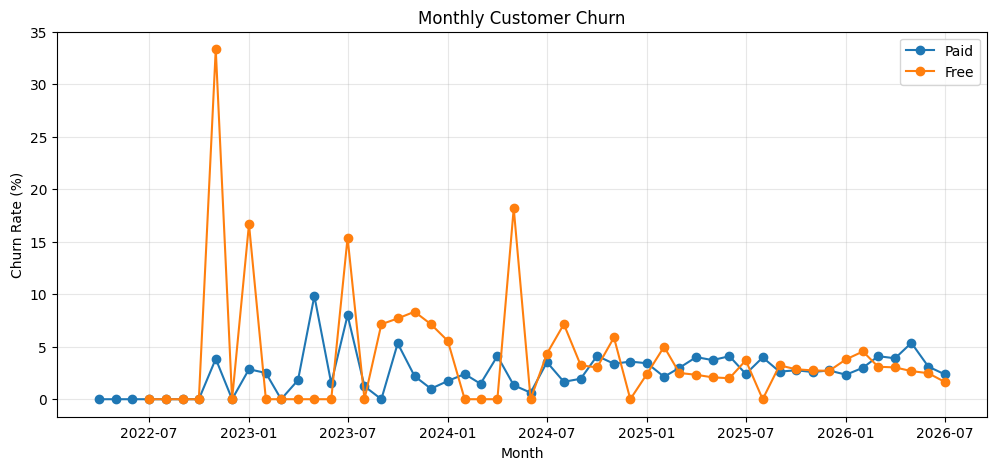

In [ ]:
plt.figure(figsize=(12,5))

plt.plot(
    monthly_paid["Month"],
    monthly_paid["Paid Churn Rate %"],
    marker="o",
    label="Paid"
)

plt.plot(
    monthly_free["Month"],
    monthly_free["Free Churn Rate %"],
    marker="o",
    label="Free"
)

plt.ylabel("Churn Rate (%)")
plt.xlabel("Month")
plt.title("Monthly Customer Churn")

plt.legend()

plt.grid(alpha=.3)

plt.show()

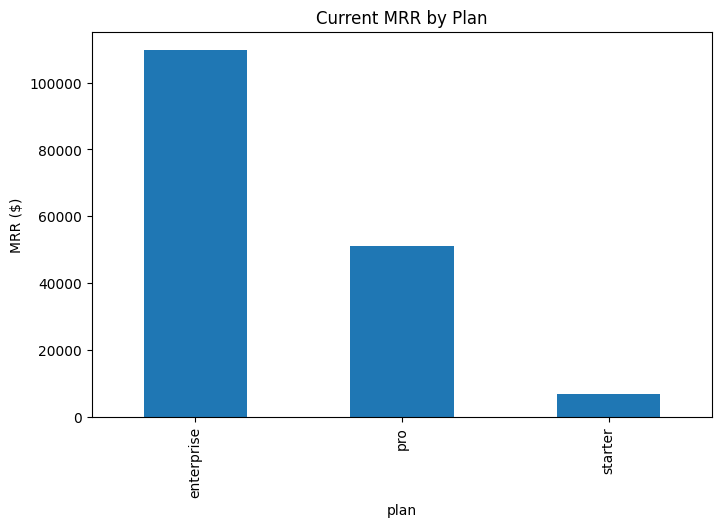

In [ ]:
mrr_by_plan["MRR"].plot(
    kind="bar",
    figsize=(8,5)
)

plt.ylabel("MRR ($)")
plt.title("Current MRR by Plan")

plt.show()